In [2]:
!unrar x "/content/dataset.rar"


UNRAR 7.00 freeware      Copyright (c) 1993-2024 Alexander Roshal


Extracting from /content/dataset.rar


Would you like to replace the existing file dataset/testing/559-ws-testing.xml
846721 bytes, modified on 2024-02-15 22:16
with a new one
846721 bytes, modified on 2024-02-15 22:16

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit Q

Program aborted


In [3]:
import xml.etree.ElementTree as ET
import pandas as pd


def xml_to_patient_dataframe(path):
    root = ET.parse(path).getroot()

    p_id, wt, ins = (
        root.attrib.get("id"),
        root.attrib.get("weight"),
        root.attrib.get("insulin_type"),
    )

    data = []

    for cat in root:
        for ev in cat:
            a = ev.attrib

            val = (
                a.get("value")
                or a.get("carbs")
                or a.get("dose")
                or a.get("duration")
            )

            det = (
                a.get("quality")
                or a.get("intensity")
                or a.get("description")
                or a.get("bwz_carb_input")
            )

            c_name = (
                f"{cat.tag}_{a.get('type')}"
                if "type" in a and cat.tag in ["meal", "bolus"]
                else cat.tag
            )

            data.append(
                {
                    "patient_id": p_id,
                    "weight_kg": wt,
                    "insulin_type": ins,
                    "metric_category": c_name,
                    "timestamp_start": a.get("ts") or a.get("ts_begin"),
                    "timestamp_end": a.get("ts_end"),
                    "value": pd.to_numeric(val, errors="coerce"),
                    "extra_details": det,
                }
            )

    df = pd.DataFrame(data)

    for col in ["timestamp_start", "timestamp_end"]:
        df[col] = pd.to_datetime(
            df[col],
            format="%d-%m-%Y %H:%M:%S",
            errors="coerce"
        )

    return df.sort_values(
        by="timestamp_start"
    ).reset_index(drop=True)


# Training dataset
train_path = "/content/dataset/training/559-ws-training.xml"
train_df = xml_to_patient_dataframe(train_path)

# Testing dataset
test_path = "/content/dataset/testing/559-ws-testing.xml"
test_df = xml_to_patient_dataframe(test_path)


# Check the results
print("TRAIN DATAFRAME")
print(train_df.head(15))
print("\nTrain shape:", train_df.shape)

print("\nTEST DATAFRAME")
print(test_df.head(15))
print("\nTest shape:", test_df.shape)

TRAIN DATAFRAME
   patient_id weight_kg insulin_type metric_category     timestamp_start  \
0         559        99      Novalog           basal 2021-12-07 00:00:00   
1         559        99      Novalog    finger_stick 2021-12-07 01:03:20   
2         559        99      Novalog    bolus_normal 2021-12-07 01:08:04   
3         559        99      Novalog    finger_stick 2021-12-07 01:08:04   
4         559        99      Novalog   glucose_level 2021-12-07 01:17:00   
5         559        99      Novalog   glucose_level 2021-12-07 01:22:00   
6         559        99      Novalog   glucose_level 2021-12-07 01:27:00   
7         559        99      Novalog   glucose_level 2021-12-07 01:32:00   
8         559        99      Novalog   glucose_level 2021-12-07 01:37:00   
9         559        99      Novalog   glucose_level 2021-12-07 01:42:00   
10        559        99      Novalog   glucose_level 2021-12-07 01:47:00   
11        559        99      Novalog   glucose_level 2021-12-07 01:52:00

In [4]:
import numpy as np
import pandas as pd

category_map = {
    "glucose_level": "glucose",
    "finger_stick": "finger_stick",
    "basal": "basal",
    "basis_heart_rate": "heart_rate",
    "basis_steps": "steps",
    "basis_air_temperature": "air_temperature",
    "basis_gsr": "gsr",
    "basis_skin_temperature": "skin_temperature",
    "meal": "meal",
    "exercise": "exercise"
}

def prepare_timeseries(df):

    data = df.copy()

    data["feature"] = data["metric_category"].map(category_map)
    data = data.dropna(subset=["feature"])

    data["value"] = pd.to_numeric(
        data["value"],
        errors="coerce"
    )

    data = data.dropna(subset=["value"])

    data["time"] = data["timestamp_start"].dt.floor("5min")

    data = (
        data.groupby(["time", "feature"])["value"]
        .mean()
        .unstack()
        .reset_index()
    )

    expected = [
        "glucose",
        "finger_stick",
        "basal",
        "heart_rate",
        "steps",
        "air_temperature",
        "gsr",
        "skin_temperature",
        "meal",
        "exercise"
    ]

    for col in expected:
        if col not in data.columns:
            data[col] = np.nan

    data = data[["time"] + expected]
    data = data.sort_values("time").reset_index(drop=True)

    return data


train_ts = prepare_timeseries(train_df)
test_ts = prepare_timeseries(test_df)

print("TRAIN:", train_ts.shape)
print("TEST :", test_ts.shape)

print("\nTraining:")
print(train_ts.head(10))

print("\nMissing values:")
print(train_ts.isna().sum())

TRAIN: (12017, 11)
TEST : (2872, 11)

Training:
feature                time  glucose  finger_stick  basal  heart_rate  steps  \
0       2021-12-07 00:00:00      NaN           NaN   0.65         NaN    NaN   
1       2021-12-07 01:00:00      NaN         107.0    NaN         NaN    NaN   
2       2021-12-07 01:05:00      NaN         107.0    NaN         NaN    NaN   
3       2021-12-07 01:15:00    101.0           NaN    NaN         NaN    NaN   
4       2021-12-07 01:20:00     98.0           NaN    NaN         NaN    NaN   
5       2021-12-07 01:25:00    104.0           NaN    NaN         NaN    NaN   
6       2021-12-07 01:30:00    112.0           NaN    NaN         NaN    NaN   
7       2021-12-07 01:35:00    120.0           NaN    NaN         NaN    NaN   
8       2021-12-07 01:40:00    127.0           NaN    NaN         NaN    NaN   
9       2021-12-07 01:45:00    135.0           NaN    NaN         NaN    NaN   

feature  air_temperature  gsr  skin_temperature  meal  exercise  
0    

In [5]:
import numpy as np
import pandas as pd

def prepare_model_data(df):
    data = df.copy()

    data["feature"] = data["metric_category"].map(category_map)
    data = data.dropna(subset=["feature"])

    data["value"] = pd.to_numeric(data["value"], errors="coerce")
    data = data.dropna(subset=["value"])

    data["time"] = data["timestamp_start"].dt.floor("5min")

    data = (
        data.groupby(["time", "feature"])["value"]
        .mean()
        .unstack()
    )

    expected = [
        "glucose",
        "finger_stick",
        "basal",
        "heart_rate",
        "steps",
        "air_temperature",
        "gsr",
        "skin_temperature",
        "meal",
        "exercise"
    ]

    for col in expected:
        if col not in data.columns:
            data[col] = np.nan

    data = data[expected]

    full_time = pd.date_range(
        start=data.index.min(),
        end=data.index.max(),
        freq="5min"
    )

    data = data.reindex(full_time)

    data.index.name = "time"

    sensor_cols = [
        "finger_stick",
        "basal",
        "heart_rate",
        "steps",
        "air_temperature",
        "gsr",
        "skin_temperature"
    ]

    data[sensor_cols] = data[sensor_cols].ffill()

    data["meal"] = data["meal"].fillna(0)
    data["exercise"] = data["exercise"].fillna(0)

    return data.reset_index()


train_ts = prepare_model_data(train_df)
test_ts = prepare_model_data(test_df)

print("TRAIN:", train_ts.shape)
print("TEST :", test_ts.shape)

print("\nMissing values:")
print(train_ts.isna().sum())

TRAIN: (12096, 11)
TEST : (2876, 11)

Missing values:
feature
time                   0
glucose             1300
finger_stick          12
basal                  0
heart_rate           155
steps                155
air_temperature      155
gsr                  155
skin_temperature     155
meal                   0
exercise               0
dtype: int64


In [6]:
def create_rf_data(df):

    data = df.copy()

    for mins in [5, 10, 15, 30, 60]:
        data[f"glucose_{mins}m"] = data["glucose"].shift(mins // 5)

    data["glucose_30m_mean"] = (
        data["glucose"]
        .shift(1)
        .rolling(6)
        .mean()
    )

    features = [
        "glucose_5m",
        "glucose_10m",
        "glucose_15m",
        "glucose_30m",
        "glucose_60m",
        "glucose_30m_mean",
        "finger_stick",
        "basal",
        "heart_rate",
        "steps",
        "air_temperature",
        "gsr",
        "skin_temperature",
        "meal",
        "exercise"
    ]

    data = data.dropna(
        subset=["glucose"] + features
    ).reset_index(drop=True)

    return data[features], data["glucose"]


X_train_rf, y_train_rf = create_rf_data(train_ts)
X_test_rf, y_test_rf = create_rf_data(test_ts)

print("X_train:", X_train_rf.shape)
print("y_train:", y_train_rf.shape)
print("X_test :", X_test_rf.shape)
print("y_test :", y_test_rf.shape)

X_train: (10166, 15)
y_train: (10166,)
X_test : (2312, 15)
y_test : (2312,)


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_rf, y_train_rf)

rf_pred = rf.predict(X_test_rf)

mae = mean_absolute_error(y_test_rf, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test_rf, rf_pred))
r2 = r2_score(y_test_rf, rf_pred)

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

results_rf = pd.DataFrame({
    "Actual": y_test_rf.values,
    "Predicted": rf_pred
})

print("\nSample predictions:")
print(results_rf.head(20))

RANDOM FOREST RESULTS
MAE  : 2.7443
RMSE : 4.3583
R²   : 0.9956

Sample predictions:
    Actual  Predicted
0    249.0    245.490
1    255.0    243.090
2    294.0    258.615
3    306.0    296.060
4    316.0    309.610
5    322.0    318.510
6    311.0    324.665
7    298.0    311.960
8    293.0    291.680
9    288.0    288.990
10   291.0    285.365
11   289.0    290.075
12   285.0    288.800
13   289.0    283.910
14   300.0    290.815
15   307.0    304.220
16   296.0    307.180
17   291.0    292.055
18   275.0    282.560
19   270.0    267.190


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

persistence_pred = X_test_rf["glucose_5m"].values

p_mae = mean_absolute_error(y_test_rf, persistence_pred)
p_rmse = np.sqrt(mean_squared_error(y_test_rf, persistence_pred))
p_r2 = r2_score(y_test_rf, persistence_pred)

print("=" * 60)
print("PERSISTENCE BASELINE")
print("=" * 60)

print(f"MAE  : {p_mae:.4f}")
print(f"RMSE : {p_rmse:.4f}")
print(f"R²   : {p_r2:.4f}")

PERSISTENCE BASELINE
MAE  : 3.4615
RMSE : 5.2736
R²   : 0.9936


In [9]:
lstm_features = [
    "glucose",
    "finger_stick",
    "basal",
    "heart_rate",
    "steps",
    "air_temperature",
    "gsr",
    "skin_temperature",
    "meal",
    "exercise"
]

def create_lstm_sequences(df, sequence_length=12):

    data = df.copy()

    data[lstm_features] = (
        data[lstm_features]
        .ffill()
        .bfill()
    )

    data["glucose"] = pd.to_numeric(
        data["glucose"],
        errors="coerce"
    )

    data = data.dropna(
        subset=["glucose"]
    ).reset_index(drop=True)

    X = []
    y = []

    for i in range(sequence_length, len(data)):
        X.append(
            data[lstm_features]
            .iloc[i-sequence_length:i]
            .values
        )

        y.append(
            data["glucose"].iloc[i]
        )

    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    return X, y


X_train_lstm, y_train_lstm = create_lstm_sequences(train_ts)
X_test_lstm, y_test_lstm = create_lstm_sequences(test_ts)

print("X_train:", X_train_lstm.shape)
print("y_train:", y_train_lstm.shape)
print("X_test :", X_test_lstm.shape)
print("y_test :", y_test_lstm.shape)

print("\nNaNs:")
print("X_train:", np.isnan(X_train_lstm).sum())
print("X_test :", np.isnan(X_test_lstm).sum())
print("y_train:", np.isnan(y_train_lstm).sum())
print("y_test :", np.isnan(y_test_lstm).sum())

X_train: (12084, 12, 10)
y_train: (12084,)
X_test : (2864, 12, 10)
y_test : (2864,)

NaNs:
X_train: 0
X_test : 0
y_train: 0
y_test : 0


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

model_lstm = Sequential([
    LSTM(32, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(16, activation="relu"),
    Dense(1)
])

model_lstm.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 27480.3457 - val_loss: 12881.7393
Epoch 2/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 8780.1357 - val_loss: 2065.1133
Epoch 3/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 2167.6482 - val_loss: 599.9332
Epoch 4/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 875.7380 - val_loss: 322.8267
Epoch 5/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 500.9273 - val_loss: 201.5019
Epoch 6/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 331.0318 - val_loss: 146.4193
Epoch 7/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 238.9994 - val_loss: 126.5619
Epoch 8/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 178.3593 - val_loss: 127.5829
Epoch 9/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 146.0034 - val_loss: 100.0581
Epoch 10/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 128.7506 - val_loss: 96.2857
Epoch 11/30
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 113.0259 - val_loss: 87.1113
Epoch 12/30
3

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lstm_pred = model_lstm.predict(
    X_test_lstm,
    verbose=0
).flatten()

lstm_mae = mean_absolute_error(
    y_test_lstm,
    lstm_pred
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        y_test_lstm,
        lstm_pred
    )
)

lstm_r2 = r2_score(
    y_test_lstm,
    lstm_pred
)

print("=" * 60)
print("LSTM RESULTS")
print("=" * 60)

print(f"MAE  : {lstm_mae:.4f}")
print(f"RMSE : {lstm_rmse:.4f}")
print(f"R²   : {lstm_r2:.4f}")

LSTM RESULTS
MAE  : 4.6419
RMSE : 7.6357
R²   : 0.9861


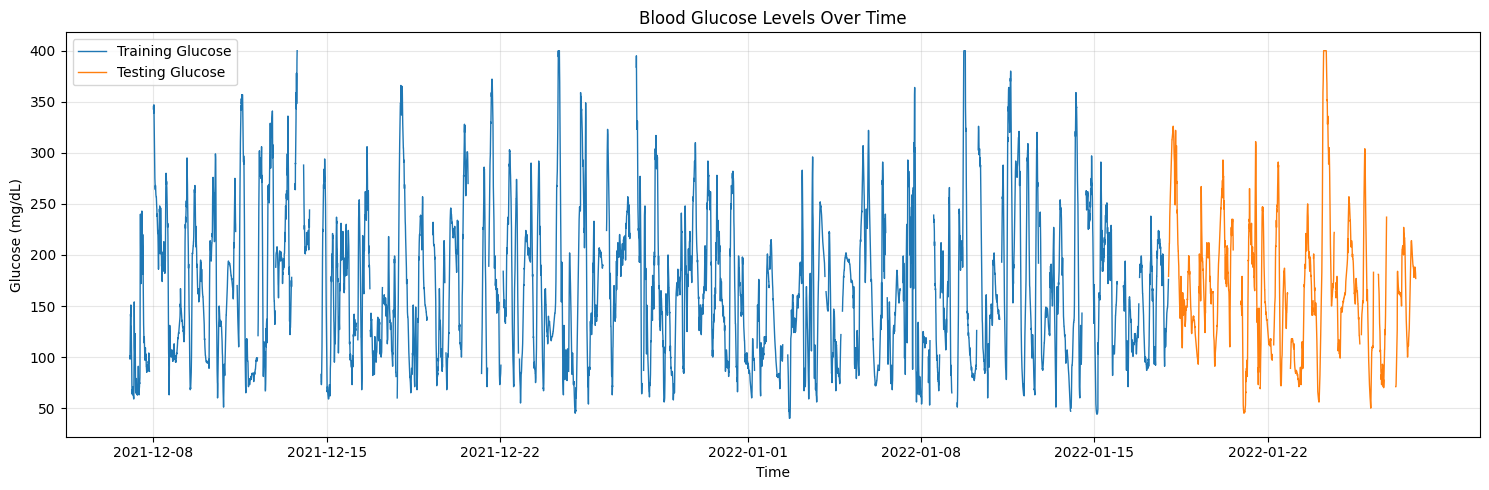

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(
    train_ts["time"],
    train_ts["glucose"],
    linewidth=1,
    label="Training Glucose"
)

plt.plot(
    test_ts["time"],
    test_ts["glucose"],
    linewidth=1,
    label="Testing Glucose"
)

plt.xlabel("Time")
plt.ylabel("Glucose (mg/dL)")
plt.title("Blood Glucose Levels Over Time")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

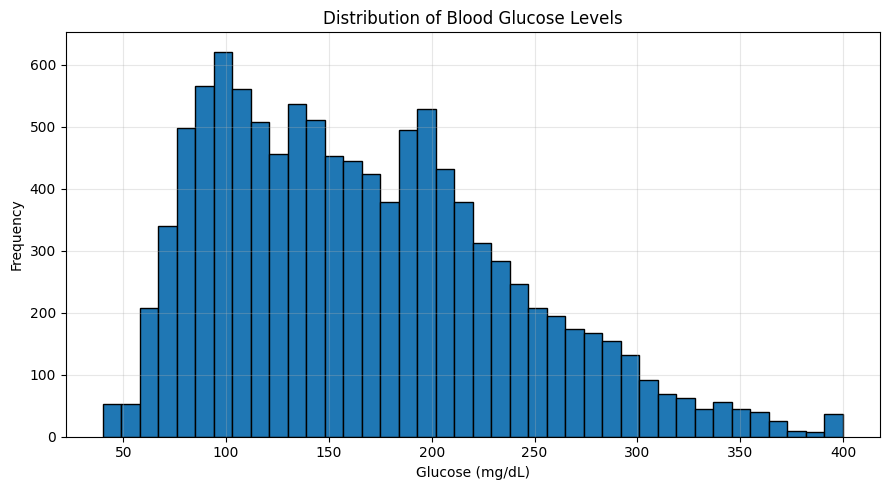

In [14]:
plt.figure(figsize=(9, 5))

plt.hist(
    train_ts["glucose"].dropna(),
    bins=40,
    edgecolor="black"
)

plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Frequency")
plt.title("Distribution of Blood Glucose Levels")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

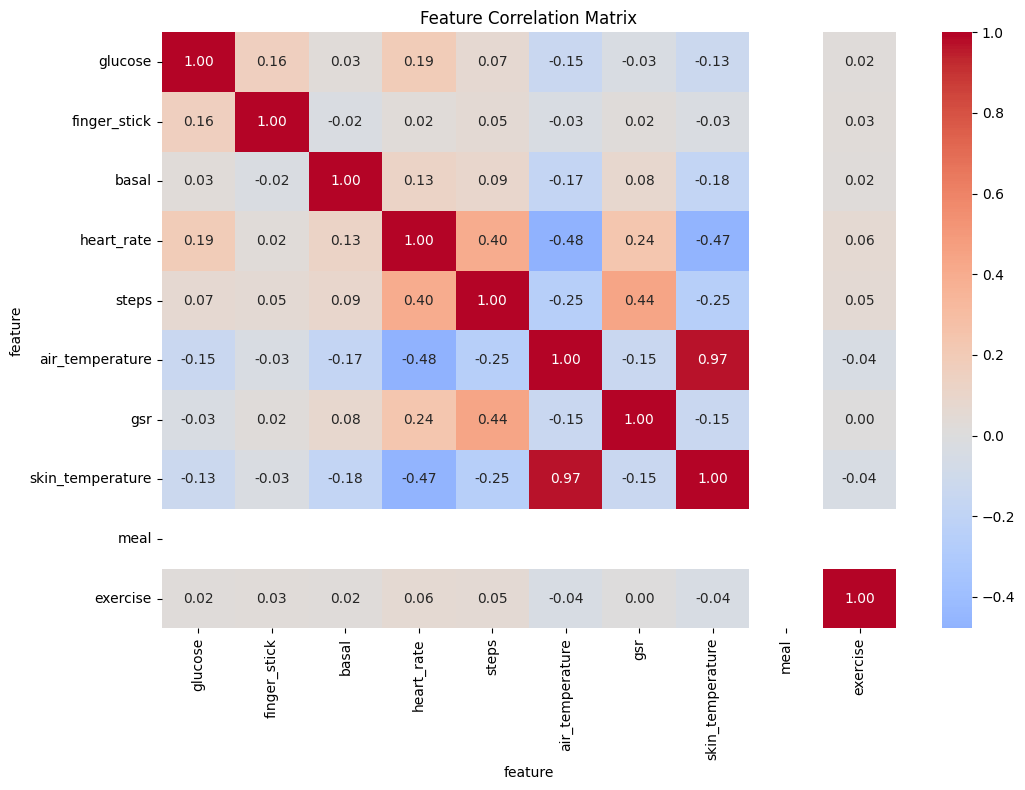

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    "glucose",
    "finger_stick",
    "basal",
    "heart_rate",
    "steps",
    "air_temperature",
    "gsr",
    "skin_temperature",
    "meal",
    "exercise"
]

corr = train_ts[corr_cols].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

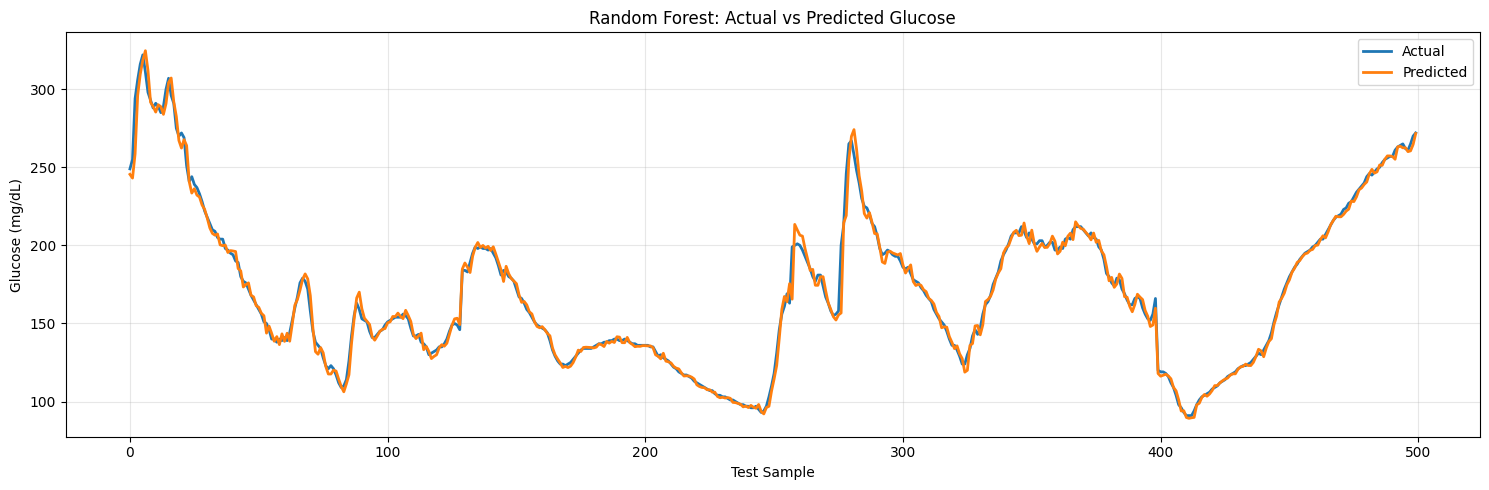

In [20]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_test_rf.values[:500],
    label="Actual",
    linewidth=2
)

plt.plot(
    rf_pred[:500],
    label="Predicted",
    linewidth=2
)

plt.xlabel("Test Sample")
plt.ylabel("Glucose (mg/dL)")
plt.title("Random Forest: Actual vs Predicted Glucose")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

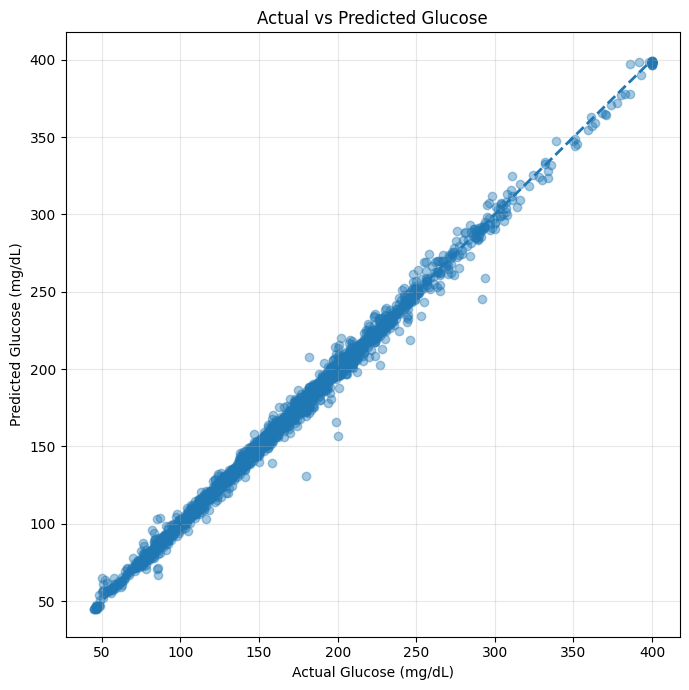

In [21]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_rf,
    rf_pred,
    alpha=0.4
)

min_val = min(y_test_rf.min(), rf_pred.min())
max_val = max(y_test_rf.max(), rf_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Glucose (mg/dL)")
plt.ylabel("Predicted Glucose (mg/dL)")
plt.title("Actual vs Predicted Glucose")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

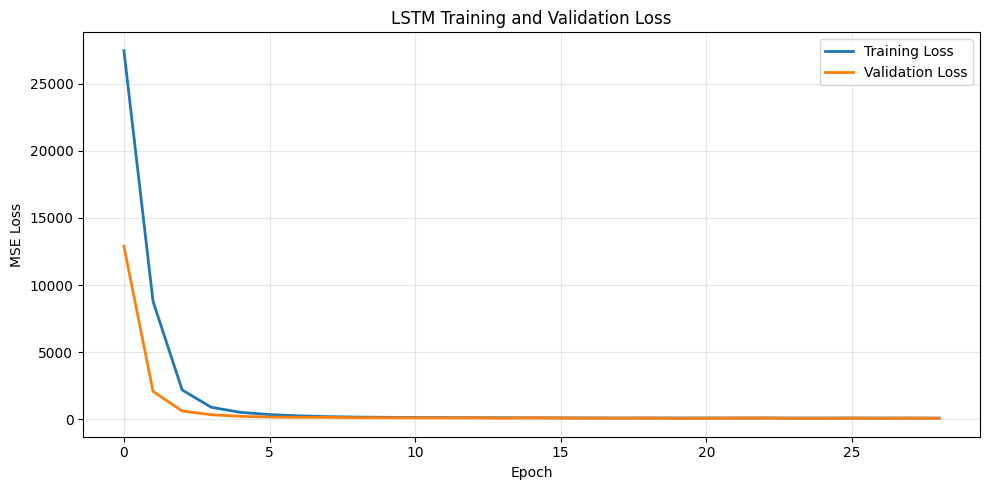

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

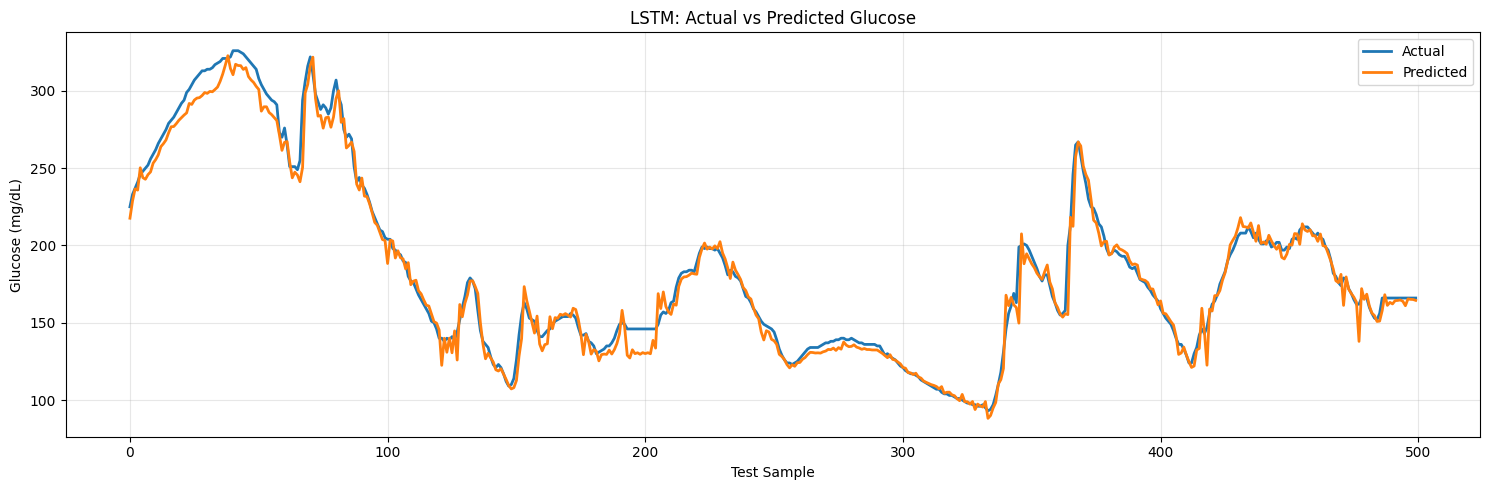

In [24]:
plt.figure(figsize=(15, 5))

plt.plot(
    y_test_lstm[:500],
    label="Actual",
    linewidth=2
)

plt.plot(
    lstm_pred[:500],
    label="Predicted",
    linewidth=2
)

plt.xlabel("Test Sample")
plt.ylabel("Glucose (mg/dL)")
plt.title("LSTM: Actual vs Predicted Glucose")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()